### Imports and CUDA

In [1]:
# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import random
import json
import os
from helper_functions import *



/home/sengkiat/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Use GPU if available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(device)

cpu


### DvXray Dataset
A large-scale dual-view X-ray baggage dataset for prohibited item detection.

- **Views:** Overlook (OL) & Side (SD) X-ray images
- **15 threat classes:** Gun, Knife, Hammer, Battery, etc.
- **Negative samples:** Benign baggage
- **Annotations:** JSON with bounding boxes

In [4]:
# DvXray Dataset
class DvXrayDataset(Dataset):
    """DvXray Dataset: dual-view X-ray baggage dataset for prohibited item detection.
    
    Args:
        transform: Optional transform to apply to each image.
        download: If True, downloads the dataset from Google Drive if not found.
    """
    
    def __init__(self, transform=None, download=False):
        # Download if requested
        if download and not check_dvxray_exists():
            download_and_extract_dvxray()
        neg_dir, pos_dir = get_directories()
        
        # Read dataset from directories
        self.samples = []
        self.labels = {}  # cache: ol_path -> list of label strings
        self.transform = transform

        # Add negative images into dataset
        for fname in os.listdir(neg_dir):
            if fname.endswith('_OL.png'):
                base = fname.replace('_OL.png', '')
                ol = os.path.join(neg_dir, base + '_OL.png')
                sd = os.path.join(neg_dir, base + '_SD.png')
                if os.path.exists(sd):
                    self.samples.append((ol, sd, 0))    # negatives = 0
                    self.labels[ol] = ["Benign"]
                else:
                    print(f"Missing SD for negative: {base}")

        # Add positive images into dataset
        for fname in os.listdir(pos_dir):
            if fname.endswith('_OL.png'):
                base = fname.replace('_OL.png', '')
                ol = os.path.join(pos_dir, base + '_OL.png')
                sd = os.path.join(pos_dir, base + '_SD.png')
                if os.path.exists(sd):
                    self.samples.append((ol, sd, 1))    # positives = 1
                    json_path = os.path.join(pos_dir, base + '.json')
                    obj_labels = []
                    if os.path.exists(json_path):
                        with open(json_path) as f:
                            data = json.load(f)
                        objects = data.get("objects")
                        if isinstance(objects, list) and len(objects) > 0:
                            for obj in objects:
                                obj_labels.append(obj["label"])
                        else:
                            obj_labels = ["Benign"]
                    else:
                        obj_labels = ["Benign"]
                    self.labels[ol] = obj_labels
                else:
                    print(f"Missing SD for positive: {base}")

        # Build label_map: Benign=0, threat classes sorted from 1
        all_labels = set()
        for label_list in self.labels.values():
            all_labels.update(label_list)

        self.label_map = {"Benign": 0}
        self.label_map.update(
            {label: i + 1 for i, label in enumerate(sorted(all_labels - {"Benign"}))}
        )
        self.num_classes = len(self.label_map)
    
    def __getitem__(self, idx):
        """Returns (image, vector, binary)"""
        ol_path, sd_path, binary_label = self.samples[idx]
        ol = Image.open(ol_path).convert('RGB')
        sd = Image.open(sd_path).convert('RGB')
        if self.transform:
            ol = self.transform(ol)
            sd = self.transform(sd)

        image = torch.cat([ol, sd], dim=0)
        multi_hot = torch.zeros(self.num_classes)
        for label_str in self.labels[ol_path]:
            if label_str in self.label_map:
                multi_hot[self.label_map[label_str]] = 1.0
    
        # (6 channel 128 x 128 image, vector of length num_classes, label)
        return image, multi_hot, binary_label  
    
    def __len__(self):
        """Return sample count"""
        return len(self.samples)
    
    def __repr__(self):
        """Return string representation of dataset"""
        pos_count = sum(1 for _, _, binary_label in self.samples if binary_label == 1)
        neg_count = len(self.samples) - pos_count
        return (f"DvXrayDataset(samples={len(self.samples)}, pos={pos_count}, neg={neg_count}, "
                f"classes={self.num_classes})\n"
                f"Labels: {', '.join(f'{v}:{k}' for k, v in self.label_map.items())}")

### Load the DvXray Dataset

In [5]:
# Default transform: resize, tensor conversion, and normalization
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Load the data (downloads if not present)
dataset = DvXrayDataset(transform=transform, download=True)
print(dataset)

DvXrayDataset(samples=16000, pos=5000, neg=11000, classes=16)
Labels: 0:Benign, 1:Bat, 2:Battery, 3:Dart, 4:Fireworks, 5:Gun, 6:Hammer, 7:Knife, 8:Lighter, 9:Pliers, 10:Pressure_vessel, 11:Razor_blade, 12:Saw_blade, 13:Scissors, 14:Screwdriver, 15:Wrench


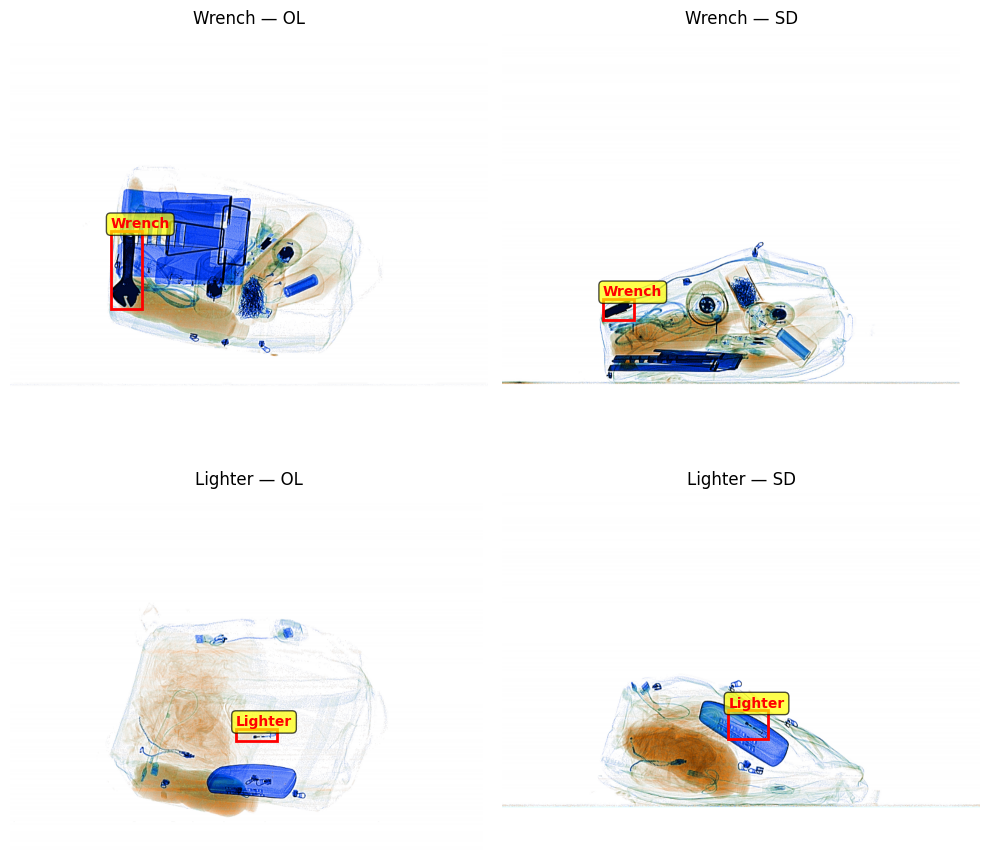

In [13]:
# Show first 2 classes
visualize_samples(dataset, n_classes=2)

### Split dataset (8-1-1) into Train-Validate-Test

In [40]:
# Split dataset into 3 subsets
train_size = int(0.8 * len(dataset))
validate_size = int(0.10 * len(dataset))
test_size = len(dataset) - train_size - validate_size

train_set, validate_set, test_set = random_split(
    dataset, [train_size, validate_size, test_size]
)

batch_size = 32
train_loader = DataLoader(train_set, batch_size, shuffle=True)
val_loader = DataLoader(validate_set, batch_size)
test_loader = DataLoader(test_set, batch_size)

print(f"Train set size: {len(train_set)}")
print(f"Validate set size: {len(validate_set)}")
print(f"Test set size: {len(test_set)}\n")
print(f"Number of classes: {dataset.num_classes}")
print(f"Sample shape: {train_set[0][0].shape}")

Train set size: 12800
Validate set size: 1600
Test set size: 1600

Number of classes: 16
Sample shape: torch.Size([6, 128, 128])


In [ ]:
class MyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(6, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(64 * 32 * 32, 128)

        # TWO HEADS
        self.fc_multi = nn.Linear(128, num_classes)
        self.fc_binary = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))

        # TWO OUTPUTS
        multi_out = self.fc_multi(x) #object
        binary_out = self.fc_binary(x) #threat/no threat

        return multi_out, binary_out

In [42]:

# Class imbalance for binary head
labels = [dataset.samples[i][2] for i in train_set.indices]
neg = labels.count(0)
pos = labels.count(1)
print(f"Class balance: {neg} negatives, {pos} positives")

weights = torch.tensor([1.0, neg / pos]).to(device)

# Multi-label: BCEWithLogitsLoss (handles multi-hot targets)
criterion_multi = nn.BCEWithLogitsLoss()
# Binary: weighted CrossEntropyLoss
criterion_binary = nn.CrossEntropyLoss(weight=weights)

Class balance: 8831 negatives, 3969 positives


In [44]:
# train the model
# model = MyCNN().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

model = MyCNN(num_classes=dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix
# train_losses, val_losses, val_accs = [], [], []
# all_preds = []
# all_labels = []

# for epoch in range(20):

#     # ================= TRAIN =================
#     model.train()
#     total_loss = 0

#     for images, multi_labels, binary_labels in train_loader:
#         images = images.to(device)
#         multi_labels = multi_labels.to(device)
#         binary_labels = binary_labels.to(device)

#         multi_out, binary_out = model(images)

#         loss_multi = criterion_multi(multi_out, multi_labels)
#         loss_binary = criterion_binary(binary_out, binary_labels)

#         loss = loss_multi + loss_binary

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     train_loss = total_loss / len(train_loader)
#     train_losses.append(train_loss)

#     # ================= VALIDATION =================
#     model.eval()
#     val_loss = 0
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for images, multi_labels, binary_labels in val_loader:
#             images = images.to(device)
#             multi_labels = multi_labels.to(device)
#             binary_labels = binary_labels.to(device)

#             multi_out, binary_out = model(images)

#             loss_multi = criterion_multi(multi_out, multi_labels)
#             loss_binary = criterion_binary(binary_out, binary_labels)

#             loss = loss_multi + loss_binary
#             val_loss += loss.item()

#             preds = torch.argmax(binary_out, dim=1)
#             correct += (preds == binary_labels).sum().item()
#             total += binary_labels.size(0)

#     val_loss = val_loss / len(val_loader)
#     val_acc = correct / total

#     val_losses.append(val_loss)
#     val_accs.append(val_acc)

#     print(f"Epoch {epoch+1}/20 | Train Loss: {train_loss:.4f} | "
#           f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# # ================= FINAL TEST =================
# model.eval()
# correct = 0
# total = 0
# printed = False
# with torch.no_grad():
#     for images, _, binary_labels in test_loader:
#         images = images.to(device)
#         binary_labels = binary_labels.to(device)

#         multi_out, binary_out = model(images)
#         preds = torch.argmax(binary_out, dim=1)

#         correct += (preds == binary_labels).sum().item()
#         total += binary_labels.size(0)
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(binary_labels.cpu().numpy())
    
#         if not printed:
#                 pred_multi = torch.argmax(multi_out, dim=1)
#                 pred_binary = torch.argmax(binary_out, dim=1)
#                 idx_to_label = {v: k for k, v in label_map.items()}
#                 print("Pred item:", [idx_to_label[i.item()] for i in pred_multi[:5]])
#                 print("Pred threat:", ["Threat" if i.item()==1 else "No Threat" for i in pred_binary[:5]])
#                 printed = True
    
# print(classification_report(all_labels, all_preds, target_names=['No Threat', 'Threat']))


# print("Final Test Accuracy:", correct / total)

Epoch 1/20 | Train Loss: 1.7078 | Val Loss: 1.1823 | Val Acc: 0.9519
Epoch 2/20 | Train Loss: 1.3859 | Val Loss: 1.1755 | Val Acc: 0.9475
Epoch 3/20 | Train Loss: 1.3250 | Val Loss: 1.1283 | Val Acc: 0.9563
Epoch 4/20 | Train Loss: 1.2903 | Val Loss: 1.1152 | Val Acc: 0.9637
Epoch 5/20 | Train Loss: 1.2693 | Val Loss: 1.1873 | Val Acc: 0.9575
Epoch 6/20 | Train Loss: 1.2455 | Val Loss: 1.2542 | Val Acc: 0.9544
Epoch 7/20 | Train Loss: 1.2275 | Val Loss: 1.1457 | Val Acc: 0.9606
Epoch 8/20 | Train Loss: 1.2164 | Val Loss: 1.9067 | Val Acc: 0.5456
Epoch 9/20 | Train Loss: 1.2228 | Val Loss: 1.3756 | Val Acc: 0.7931
Epoch 10/20 | Train Loss: 1.1936 | Val Loss: 1.0403 | Val Acc: 0.9663
Epoch 11/20 | Train Loss: 1.1904 | Val Loss: 1.0511 | Val Acc: 0.9637
Epoch 12/20 | Train Loss: 1.1894 | Val Loss: 1.0651 | Val Acc: 0.9581
Epoch 13/20 | Train Loss: 1.1646 | Val Loss: 1.1145 | Val Acc: 0.9394
Epoch 14/20 | Train Loss: 1.1607 | Val Loss: 1.0827 | Val Acc: 0.9544
Epoch 15/20 | Train Loss: 1.1

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
train_losses, val_losses, val_accs = [], [], []
all_preds = []
all_labels = []
best_val_acc = 0

# Multi-class names for report
idx_to_label = {v: k for k, v in dataset.label_map.items()}
NUM_CLASSES = dataset.num_classes

for epoch in range(20):

    # ================= TRAIN =================
    model.train()
    total_loss = 0

    for images, multi_labels, binary_labels in train_loader:
        images = images.to(device)
        multi_labels = multi_labels.to(device)
        binary_labels = binary_labels.to(device)

        multi_out, binary_out = model(images)

        loss_multi = criterion_multi(multi_out, multi_labels)
        loss_binary = criterion_binary(binary_out, binary_labels)

        loss = loss_multi + loss_binary

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, multi_labels, binary_labels in val_loader:
            images = images.to(device)
            multi_labels = multi_labels.to(device)
            binary_labels = binary_labels.to(device)

            multi_out, binary_out = model(images)

            loss_multi = criterion_multi(multi_out, multi_labels)
            loss_binary = criterion_binary(binary_out, binary_labels)

            loss = loss_multi + loss_binary
            val_loss += loss.item()

            preds = torch.argmax(binary_out, dim=1)
            correct += (preds == binary_labels).sum().item()
            total += binary_labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/20 | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_cnn_model.pth')
        print(f"  → Best model saved (val_acc: {val_acc:.4f})")

# Load best weights before testing
model.load_state_dict(torch.load('best_cnn_model.pth', weights_only=True))
print(f"Loaded best model with val_acc: {best_val_acc:.4f}")

# ================= FINAL TEST =================
model.eval()
correct = 0
total = 0
printed = False
with torch.no_grad():
    for images, _, binary_labels in test_loader:
        images = images.to(device)
        binary_labels = binary_labels.to(device)

        multi_out, binary_out = model(images)
        preds = torch.argmax(binary_out, dim=1)

        correct += (preds == binary_labels).sum().item()
        total += binary_labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(binary_labels.cpu().numpy())
    
        if not printed:
            # Show multi-label predictions (top predicted classes)
            probs = torch.sigmoid(multi_out)
            topk = torch.topk(probs[0], k=3)
            top_labels = [idx_to_label[i.item()] for i in topk.indices]
            top_probs = [f"{p:.3f}" for p in topk.values]
            print(f"Top predictions: {list(zip(top_labels, top_probs))}")

            pred_binary = torch.argmax(binary_out, dim=1)
            print("Pred threat:", ["Threat" if i.item()==1 else "No Threat" for i in pred_binary[:5]])
            printed = True
    
print(classification_report(all_labels, all_preds, target_names=['No Threat', 'Threat']))
print("Final Test Accuracy:", correct / total)

KeyboardInterrupt: 